## Imports

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller

from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

## Extract and Process the Dataset

In [174]:
df = pd.read_csv('Unemployment in America Per US State.csv')
df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,1,Alabama,1976,1,"2,605,000","1,486,509",57.1,"1,387,606",53.3,"98,903",6.7
1,2,Alaska,1976,1,"232,000","160,709",69.3,"149,226",64.3,"11,483",7.1
2,4,Arizona,1976,1,"1,621,000","963,980",59.5,"865,261",53.4,"98,719",10.2
3,5,Arkansas,1976,1,"1,536,000","889,912",57.9,"825,233",53.7,"64,679",7.3
4,6,California,1976,1,"15,621,000","9,770,553",62.5,"8,873,133",56.8,"897,420",9.2


In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31747 entries, 0 to 31746
Data columns (total 11 columns):
 #   Column                                                     Non-Null Count  Dtype
---  ------                                                     --------------  -----
 0   FIPS Code                                                  31747 non-null  int64
 1   State/Area                                                 31747 non-null  str  
 2   Year                                                       31747 non-null  int64
 3   Month                                                      31747 non-null  int64
 4   Total Civilian Non-Institutional Population in State/Area  31747 non-null  str  
 5   Total Civilian Labor Force in State/Area                   31747 non-null  str  
 6   Percent (%) of State/Area's Population                     31747 non-null  str  
 7   Total Employment in State/Area                             31747 non-null  str  
 8   Percent (%) of Labor Force Employed i

In [176]:
df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area,date
0,1,Alabama,1976,1,"2,605,000","1,486,509",57.1,"1,387,606",53.3,"98,903",6.7,1976-01-01
1,2,Alaska,1976,1,"232,000","160,709",69.3,"149,226",64.3,"11,483",7.1,1976-01-01
2,4,Arizona,1976,1,"1,621,000","963,980",59.5,"865,261",53.4,"98,719",10.2,1976-01-01
3,5,Arkansas,1976,1,"1,536,000","889,912",57.9,"825,233",53.7,"64,679",7.3,1976-01-01
4,6,California,1976,1,"15,621,000","9,770,553",62.5,"8,873,133",56.8,"897,420",9.2,1976-01-01


In [177]:

df['Total Unemployment in State/Area'] = pd.to_numeric(
    df['Total Unemployment in State/Area']
    .str.replace(",", "", regex=False),
    errors='coerce'
)

df['Total Civilian Labor Force in State/Area'] = pd.to_numeric(
    df['Total Civilian Labor Force in State/Area']
    .str.replace(",", "", regex=False),
    errors='coerce'
)

df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area,date
0,1,Alabama,1976,1,"2,605,000",1486509.0,57.1,"1,387,606",53.3,98903.0,6.7,1976-01-01
1,2,Alaska,1976,1,"232,000",160709.0,69.3,"149,226",64.3,11483.0,7.1,1976-01-01
2,4,Arizona,1976,1,"1,621,000",963980.0,59.5,"865,261",53.4,98719.0,10.2,1976-01-01
3,5,Arkansas,1976,1,"1,536,000",889912.0,57.9,"825,233",53.7,64679.0,7.3,1976-01-01
4,6,California,1976,1,"15,621,000",9770553.0,62.5,"8,873,133",56.8,897420.0,9.2,1976-01-01


In [178]:
series = (
    df.groupby('date')
    .agg({
        'Total Unemployment in State/Area': 'sum',
        'Total Civilian Labor Force in State/Area': 'sum'
    })
)
 
series['unemployment_rate'] = (
    series['Total Unemployment in State/Area'] /
    series['Total Civilian Labor Force in State/Area']
) * 100

series = series.drop(columns=['Total Unemployment in State/Area', 'Total Civilian Labor Force in State/Area'])
series.dropna()

series.head()

,unemployment_rate
date,
1976-01-01,7.941620
1976-02-01,7.941561
1976-03-01,7.916780
1976-04-01,7.849169
1976-05-01,7.779528


In [179]:
# Remove the last two months because there is missing data
series = series.iloc[:-2]
series.tail()

,unemployment_rate
date,
2025-05-01,4.258522
2025-06-01,4.244684
2025-07-01,4.258767
2025-08-01,4.266550
2025-09-01,4.314338


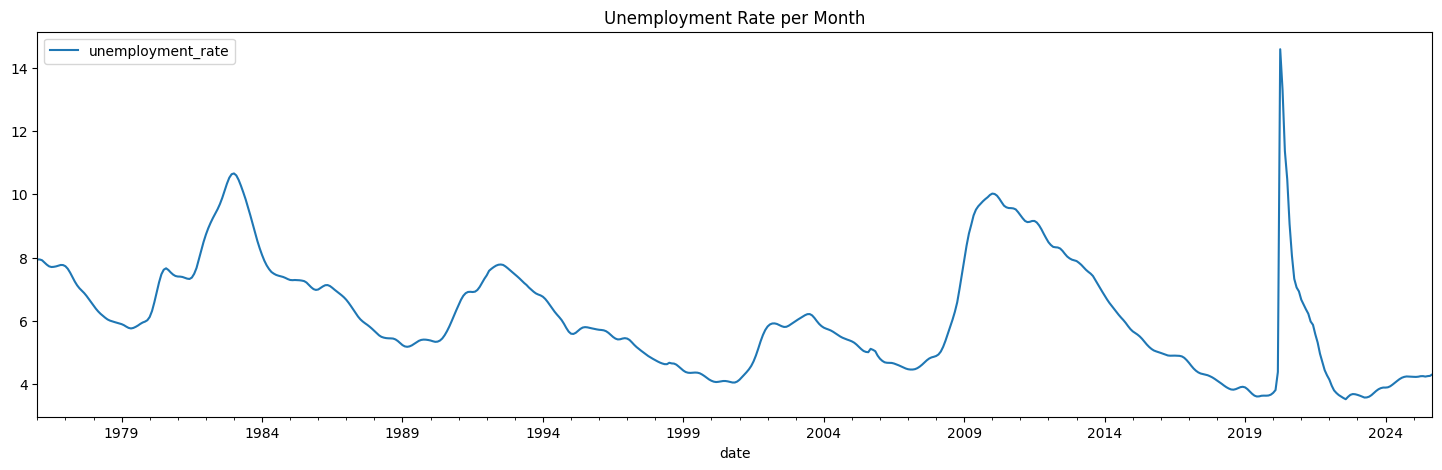

In [180]:
series.plot(figsize=(18, 5))
plt.title('Unemployment Rate per Month')
plt.show()

## Slipt the Series

In [181]:
H = 12  # horizonte de teste: 12 meses

train = series.iloc[:-H]
test  = series.iloc[-H:]

print(f'train: {train.size} | test: {test.size}')
print(f'test: {test.index[0].date()} → {test.index[-1].date()}')

train: 585 | test: 12
test: 2024-10-01 → 2025-09-01


## Base Models

In [182]:
y       = series['unemployment_rate']
y_train = train['unemployment_rate']
y_test  = test['unemployment_rate']

# Preenchido pelas células abaixo para a tabela comparativa final
sumario = {}

## Média Móvel

Média Móvel:


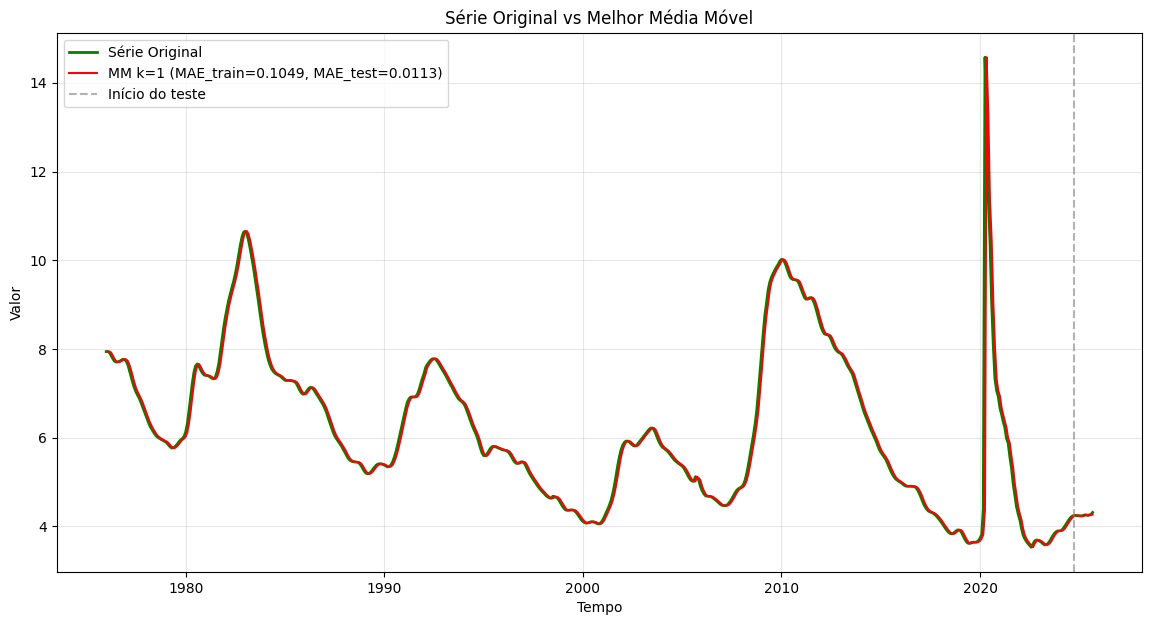

,k,MAE_train,MAE_test
0,1,0.104918,0.011344
1,2,0.151930,0.013766
2,3,0.192743,0.016421
3,5,0.272130,0.024332
4,7,0.342761,0.040156
5,12,0.500372,0.098867
6,24,0.829398,0.282552


In [183]:
print("Média Móvel:")

ks = [1, 2, 3, 5, 7, 12, 24]
k_max = max(ks)

mm_detalhado = {}
resultado = pd.DataFrame()

for k in ks:
    # 1-step-ahead na série inteira: pred[t] = média(y[t-k] ... y[t-1])
    pred_full = y.rolling(window=k).mean().shift(1)
    mm_detalhado[f'mme_{k}'] = pred_full

    # MAE_train na janela comum (mesmos índices para todos os k)
    pred_train = pred_full.loc[y_train.index].iloc[k_max:]
    real_train = y_train.iloc[k_max:]
    mae_train = mean_absolute_error(real_train, pred_train)

    # MAE_test 1-step-ahead (usa valores reais até t-1)
    pred_test = pred_full.loc[y_test.index]
    mae_test = mean_absolute_error(y_test, pred_test)

    resultado = pd.concat([resultado, pd.DataFrame({
        'k': [k], 'MAE_train': [mae_train], 'MAE_test': [mae_test]
    })], ignore_index=True)

# escolha do k pelo MAE_train (sem ver o test)
melhor_idx = resultado['MAE_train'].idxmin()
melhor_k = int(resultado.loc[melhor_idx, 'k'])
melhor_mae_train = resultado.loc[melhor_idx, 'MAE_train']
melhor_mae_test  = resultado.loc[melhor_idx, 'MAE_test']

sumario['Média Móvel'] = {
    'Parâmetro': f'k={melhor_k}',
    'MAE_train': melhor_mae_train,
    'MAE_test':  melhor_mae_test,
}

melhor_previsao = mm_detalhado[f'mme_{melhor_k}']

plt.figure(figsize=(14, 7))
plt.plot(y.index, y.values, label='Série Original', color='green', linewidth=2)
plt.plot(melhor_previsao.index, melhor_previsao.values,
         linewidth=1.5, color='red',
         label=f'MM k={melhor_k} (MAE_train={melhor_mae_train:.4f}, MAE_test={melhor_mae_test:.4f})')
plt.axvline(y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Início do teste')
plt.title('Série Original vs Melhor Média Móvel')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

display(resultado)

## Média Acumulada

In [184]:
# Média acumulada 1-step-ahead: pred[t] = média(y[0] ... y[t-1])
previsao = y.expanding().mean().shift(1)

pred_train = previsao.loc[y_train.index].iloc[1:]
real_train = y_train.iloc[1:]
mae_train = mean_absolute_error(real_train, pred_train)

pred_test = previsao.loc[y_test.index]
mae_test  = mean_absolute_error(y_test, pred_test)

sumario['Média Acumulada'] = {
    'Parâmetro': '-',
    'MAE_train': mae_train,
    'MAE_test':  mae_test,
}

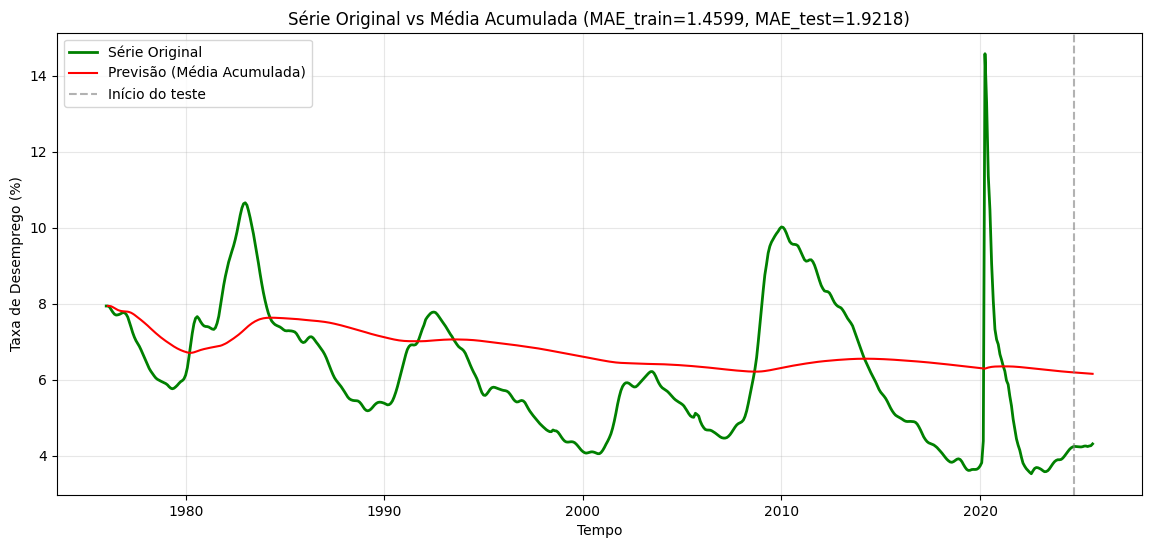

,Parâmetro,MAE_train,MAE_test
0,-,1.459946,1.921825


In [185]:
plt.figure(figsize=(14, 6))
plt.plot(y.index, y.values, label='Série Original', color='green', linewidth=2)
plt.plot(previsao.index, previsao.values, label='Previsão (Média Acumulada)', color='red', linewidth=1.5)
plt.axvline(y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Início do teste')
plt.title(f'Série Original vs Média Acumulada (MAE_train={mae_train:.4f}, MAE_test={mae_test:.4f})')
plt.xlabel('Tempo')
plt.ylabel('Taxa de Desemprego (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

resultado = pd.DataFrame({
    'Parâmetro': ['-'],
    'MAE_train': [mae_train],
    'MAE_test':  [mae_test],
})
display(resultado)

### EMA

EMA:


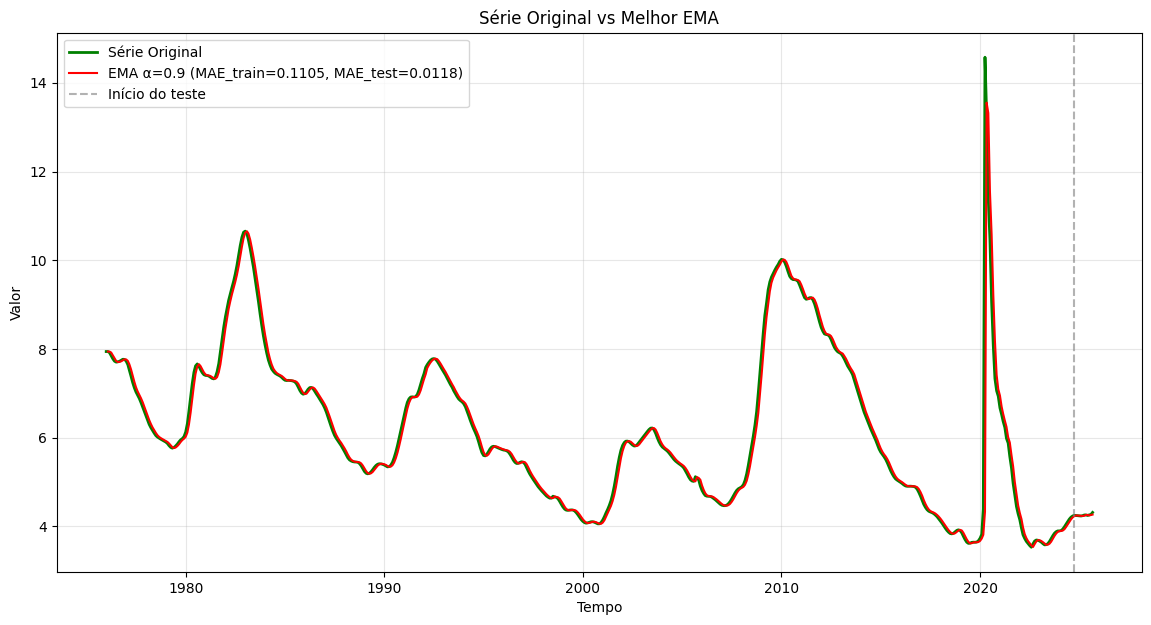

,Alpha,MAE_train,MAE_test
0,0.1,0.597377,0.146453
1,0.2,0.366760,0.073640
2,0.3,0.268741,0.036802
3,0.4,0.213695,0.022793
4,0.5,0.178334,0.016744
5,0.6,0.154899,0.014269
6,0.7,0.136799,0.013058
7,0.8,0.122053,0.012162
8,0.9,0.110541,0.011765


In [186]:
print("EMA:")

alphas = np.round(np.arange(0.1, 1.0, 0.1), 2)

ema_detalhado = {}
resultado = pd.DataFrame()

for alpha in alphas:
    # 1-step-ahead: EMA até t-1 sobre todos os valores reais
    pred_full = y.ewm(alpha=alpha, adjust=False).mean().shift(1)
    ema_detalhado[f'ema_{alpha}'] = pred_full

    pred_train = pred_full.loc[y_train.index].iloc[1:]
    real_train = y_train.iloc[1:]
    mae_train = mean_absolute_error(real_train, pred_train)

    pred_test = pred_full.loc[y_test.index]
    mae_test  = mean_absolute_error(y_test, pred_test)

    resultado = pd.concat([resultado, pd.DataFrame({
        'Alpha': [alpha], 'MAE_train': [mae_train], 'MAE_test': [mae_test]
    })], ignore_index=True)

melhor_idx = resultado['MAE_train'].idxmin()
melhor_alpha = resultado.loc[melhor_idx, 'Alpha']
melhor_mae_train = resultado.loc[melhor_idx, 'MAE_train']
melhor_mae_test  = resultado.loc[melhor_idx, 'MAE_test']

sumario['EMA'] = {
    'Parâmetro': f'α={melhor_alpha}',
    'MAE_train': melhor_mae_train,
    'MAE_test':  melhor_mae_test,
}

melhor_previsao = ema_detalhado[f'ema_{melhor_alpha}']

plt.figure(figsize=(14, 7))
plt.plot(y.index, y.values, label='Série Original', color='green', linewidth=2)
plt.plot(melhor_previsao.index, melhor_previsao.values,
         linewidth=1.5, color='red',
         label=f'EMA α={melhor_alpha} (MAE_train={melhor_mae_train:.4f}, MAE_test={melhor_mae_test:.4f})')
plt.axvline(y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Início do teste')
plt.title('Série Original vs Melhor EMA')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

display(resultado)

## Seasonal Naive

In [187]:
# Sazonalidades candidatas: lags sensatos para dados mensais
ss = [1, 2, 3, 6, 12, 24]
s_max = max(ss)

sazonal_detalhado = {}
resultado = pd.DataFrame()

for s in ss:
    # 1-step-ahead: pred[t] = y[t-s]
    pred_full = y.shift(s)
    sazonal_detalhado[f'szn_{s}'] = pred_full

    # janela comum (mesmos índices p/ todos os s) — corrige o regime de avaliação
    pred_train = pred_full.loc[y_train.index].iloc[s_max:]
    real_train = y_train.iloc[s_max:]
    mae_train = mean_absolute_error(real_train, pred_train)

    pred_test = pred_full.loc[y_test.index]
    mae_test  = mean_absolute_error(y_test, pred_test)

    resultado = pd.concat([resultado, pd.DataFrame({
        'Sazonalidade': [s], 'MAE_train': [mae_train], 'MAE_test': [mae_test]
    })], ignore_index=True)

Seasonal Naive:


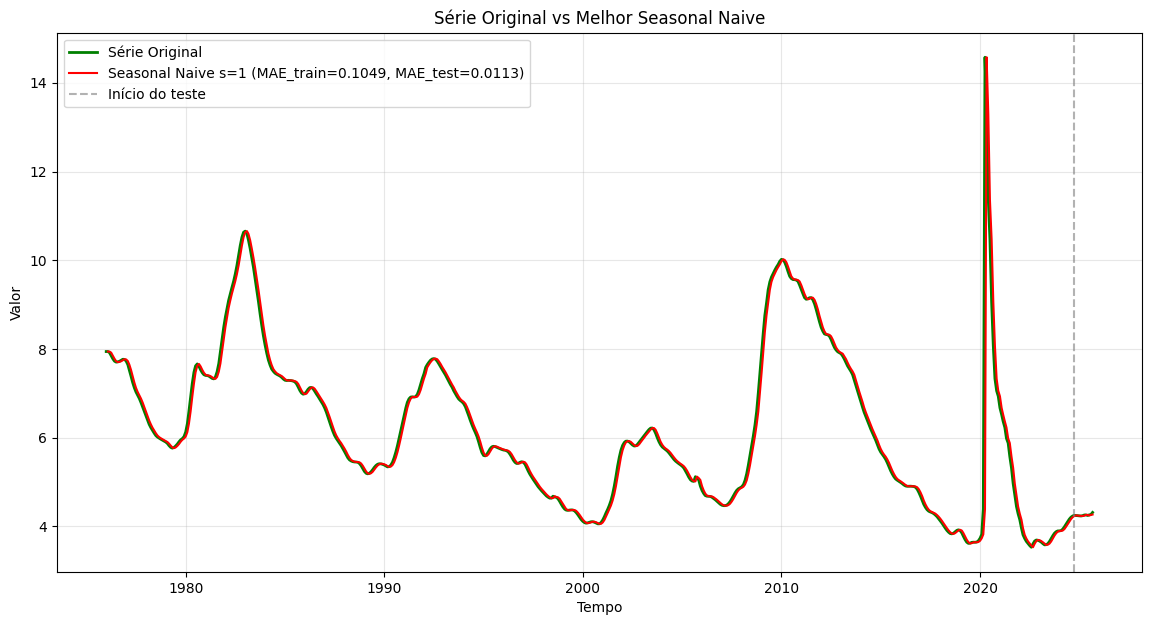

,Sazonalidade,MAE_train,MAE_test
0,1,0.104918,0.011344
1,2,0.204013,0.016978
2,3,0.294184,0.022872
3,6,0.528853,0.070016
4,12,0.915576,0.243150
5,24,1.512883,0.592977


In [188]:
print("Seasonal Naive:")

melhor_idx = resultado['MAE_train'].idxmin()
melhor_s = int(resultado.loc[melhor_idx, 'Sazonalidade'])
melhor_mae_train = resultado.loc[melhor_idx, 'MAE_train']
melhor_mae_test  = resultado.loc[melhor_idx, 'MAE_test']

sumario['Seasonal Naive'] = {
    'Parâmetro': f's={melhor_s}',
    'MAE_train': melhor_mae_train,
    'MAE_test':  melhor_mae_test,
}

melhor_previsao = sazonal_detalhado[f'szn_{melhor_s}']

plt.figure(figsize=(14, 7))
plt.plot(y.index, y.values, label='Série Original', color='green', linewidth=2)
plt.plot(melhor_previsao.index, melhor_previsao.values,
         linewidth=1.5, color='red',
         label=f'Seasonal Naive s={melhor_s} (MAE_train={melhor_mae_train:.4f}, MAE_test={melhor_mae_test:.4f})')
plt.axvline(y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Início do teste')
plt.title('Série Original vs Melhor Seasonal Naive')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

display(resultado.sort_values('MAE_train'))

## Delta

In [189]:
# Janelas candidatas (mesma escala das outras células de tuning)
janelas = [1, 2, 3, 6, 12, 24]
j_max = max(janelas)

delta_detalhado = {}

for janela in janelas:
    # 1-step-ahead: pred[t] = y[t-1] + (y[t-1] - y[t-1-janela]) / janela
    pred_full = y.shift(1) + (y.shift(1) - y.shift(1 + janela)) / janela
    delta_detalhado[f'delta_{janela}'] = pred_full

Delta:


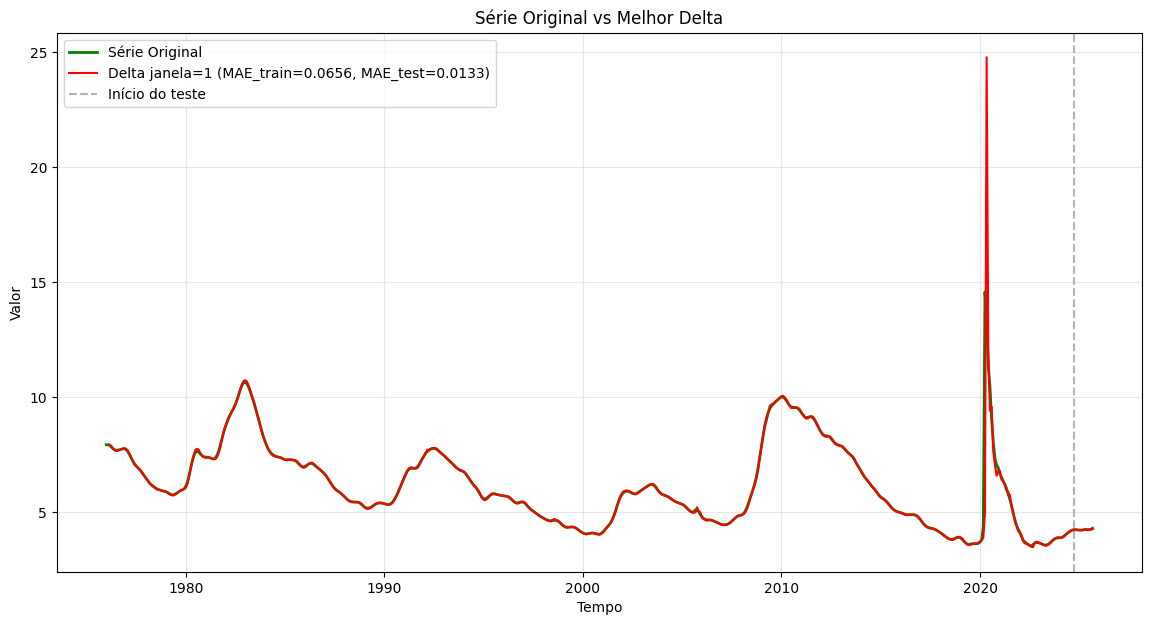

,janela,MAE_train,MAE_test
0,1,0.065554,0.013319
1,2,0.073615,0.014947
2,3,0.080452,0.016500
3,6,0.097357,0.021092
4,12,0.100563,0.023801
5,24,0.112404,0.022679


In [190]:
print("Delta:")

resultado = pd.DataFrame()

for janela in janelas:
    pred_full = delta_detalhado[f'delta_{janela}']

    # janela comum (mesmos índices p/ todas as janelas) — corrige o regime de avaliação
    pred_train = pred_full.loc[y_train.index].iloc[j_max + 1:]
    real_train = y_train.iloc[j_max + 1:]
    mae_train = mean_absolute_error(real_train, pred_train)

    pred_test = pred_full.loc[y_test.index]
    mae_test  = mean_absolute_error(y_test, pred_test)

    resultado = pd.concat([resultado, pd.DataFrame({
        'janela': [janela], 'MAE_train': [mae_train], 'MAE_test': [mae_test]
    })], ignore_index=True)

melhor_idx = resultado['MAE_train'].idxmin()
melhor_janela = int(resultado.loc[melhor_idx, 'janela'])
melhor_mae_train = resultado.loc[melhor_idx, 'MAE_train']
melhor_mae_test  = resultado.loc[melhor_idx, 'MAE_test']

sumario['Delta'] = {
    'Parâmetro': f'janela={melhor_janela}',
    'MAE_train': melhor_mae_train,
    'MAE_test':  melhor_mae_test,
}

melhor_previsao = delta_detalhado[f'delta_{melhor_janela}']

plt.figure(figsize=(14, 7))
plt.plot(y.index, y.values, label='Série Original', color='green', linewidth=2)
plt.plot(melhor_previsao.index, melhor_previsao.values,
         linewidth=1.5, color='red',
         label=f'Delta janela={melhor_janela} (MAE_train={melhor_mae_train:.4f}, MAE_test={melhor_mae_test:.4f})')
plt.axvline(y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Início do teste')
plt.title('Série Original vs Melhor Delta')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

display(resultado.sort_values('MAE_train'))

## Comparativo entre Base Models

In [191]:
comparativo = (
    pd.DataFrame.from_dict(sumario, orient='index')
    .rename_axis('Modelo')
    .reset_index()
    .sort_values('MAE_test')
    .reset_index(drop=True)
)

display(comparativo)

,Modelo,Parâmetro,MAE_train,MAE_test
0,Média Móvel,k=1,0.104918,0.011344
1,Seasonal Naive,s=1,0.104918,0.011344
2,EMA,α=0.9,0.110541,0.011765
3,Delta,janela=1,0.065554,0.013319
4,Média Acumulada,-,1.459946,1.921825
